In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load and clean the data (just like we did in Notebook 1)
df = pd.read_csv('../data/aqi_dataset.csv')
df.fillna(df.median(), inplace=True)

# Separate the "Features" (X) from the "Target" we want to predict (y)
X = df.drop('AQI', axis=1) # Everything EXCEPT AQI
y = df['AQI'] # ONLY AQI

In [2]:
# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 3. Train the model (This is where the actual "learning" happens!)
rf_model.fit(X_train, y_train)

# 4. Make predictions on the hidden 20% of data
rf_predictions = rf_model.predict(X_test)

# 5. Grade the model's performance
rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest RMSE (Error Rate): {rmse:.2f}")
print(f"Random Forest R-squared (Accuracy): {r2:.2f}")

Random Forest RMSE (Error Rate): 50.39
Random Forest R-squared (Accuracy): 0.22


In [3]:
from xgboost import XGBRegressor

# 1. Initialize the XGBoost model
# We are adding some basic tuning parameters to help it learn better
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

# 2. Train the model
xgb_model.fit(X_train, y_train)

# 3. Make predictions
xgb_predictions = xgb_model.predict(X_test)

# 4. Grade the model
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print(f"XGBoost RMSE (Error Rate): {xgb_rmse:.2f}")
print(f"XGBoost R-squared (Accuracy): {xgb_r2:.2f}")

XGBoost RMSE (Error Rate): 49.40
XGBoost R-squared (Accuracy): 0.25


In [5]:
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# --- UPGRADE 1: Feature Engineering ---
df['stagnation_index'] = df['industrial_activity'] / (df['wind_speed'] + 0.1)

# THE BUG FIX: Destroy any "infinity" values created by the division
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(), inplace=True)

# Re-split the clean data
X = df.drop('AQI', axis=1)
y = df['AQI']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# --- UPGRADE 2: Hyperparameter Tuning (Grid Search) ---
print("Initiating Grid Search... Please wait, testing multiple models!")

param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 9]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=3, 
    scoring='r2',
    verbose=1 
)

# Run the massive test safely
grid_search.fit(X_train, y_train)

best_xgb_model = grid_search.best_estimator_


# --- UPGRADE 3: Grade the Final Model ---
best_predictions = best_xgb_model.predict(X_test)
best_rmse = np.sqrt(mean_squared_error(y_test, best_predictions))
best_r2 = r2_score(y_test, best_predictions)

print("\n--- FINAL OPTIMIZED RESULTS ---")
print(f"Optimized XGBoost RMSE (Error Rate): {best_rmse:.2f}")
print(f"Optimized XGBoost R-squared (Accuracy): {best_r2:.2f}")
print(f"Best Settings Chosen: {grid_search.best_params_}")

Initiating Grid Search... Please wait, testing multiple models!
Fitting 3 folds for each of 27 candidates, totalling 81 fits

--- FINAL OPTIMIZED RESULTS ---
Optimized XGBoost RMSE (Error Rate): 48.91
Optimized XGBoost R-squared (Accuracy): 0.27
Best Settings Chosen: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}


In [6]:
import joblib

# Overwrite the old model with the new, optimized one
joblib.dump(best_xgb_model, '../models/xgboost_aqi_model.pkl')

print("Optimized Pro-Model saved successfully! Ready for the Dashboard.")

Optimized Pro-Model saved successfully! Ready for the Dashboard.


Loading data and engineering features...
Training models... This may take a minute or two.
Training Linear Regression...
Training Random Forest...
Training XGBoost...
Training SVR (Support Vector)...
Training ANN (Deep Learning)...

--- COMPARATIVE ANALYSIS RESULTS ---
               Model  RMSE (Error)  R-Squared (Accuracy)
   Linear Regression     48.461168              0.281249
 ANN (Deep Learning)     48.546061              0.278729
SVR (Support Vector)     48.824637              0.270427
             XGBoost     48.909612              0.267885
       Random Forest     50.403778              0.222471


C:\Users\PARTHIV\AppData\Local\Temp\ipykernel_10344\4226021865.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE (Error)', y='Model', data=results_df, palette='viridis')


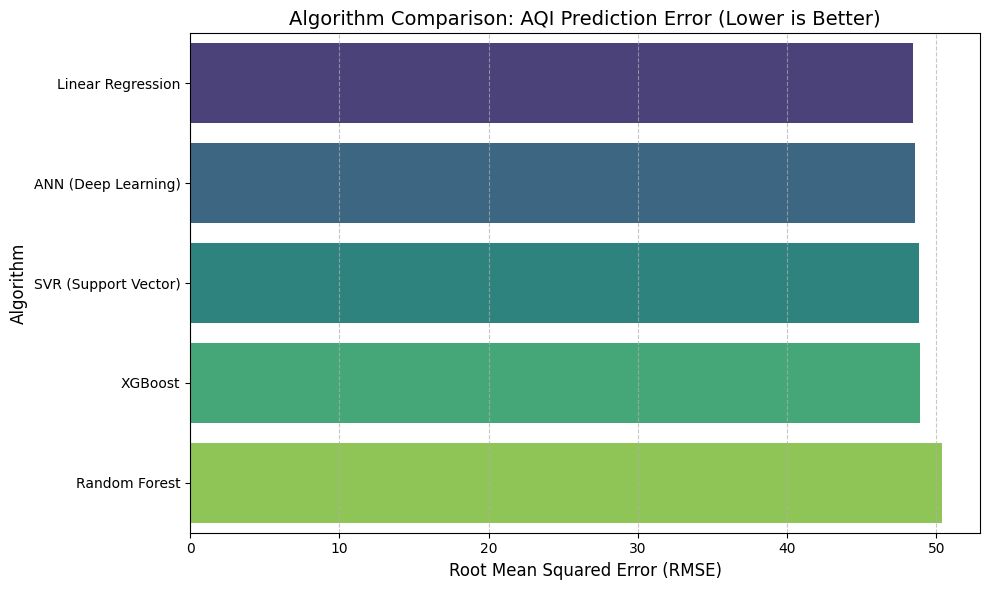

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor # This is the ANN!

print("Loading data and engineering features...")
# 1. Load and Prep the Data (including your Stagnation Index)
df = pd.read_csv('../data/aqi_dataset.csv')
df.fillna(df.median(), inplace=True)
df['stagnation_index'] = df['industrial_activity'] / (df['wind_speed'] + 0.1)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(), inplace=True)

X = df.drop('AQI', axis=1)
y = df['AQI']

# 2. Split and Scale the Data
# Neural Networks and SVMs will fail if the data isn't scaled!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Initialize the Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5, random_state=42),
    "SVR (Support Vector)": SVR(kernel='rbf', C=100, gamma=0.1),
    "ANN (Deep Learning)": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# 4. Train and Evaluate All Models
results = []

print("Training models... This may take a minute or two.")
for name, model in models.items():
    print(f"Training {name}...")
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    predictions = model.predict(X_test_scaled)
    
    # Grade the model
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    # Save the results
    results.append({"Model": name, "RMSE (Error)": rmse, "R-Squared (Accuracy)": r2})

# 5. Display the Results in a Dataframe
results_df = pd.DataFrame(results).sort_values(by="RMSE (Error)")
print("\n--- COMPARATIVE ANALYSIS RESULTS ---")
print(results_df.to_string(index=False))

# 6. Plot the Final Comparative Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='RMSE (Error)', y='Model', data=results_df, palette='viridis')
plt.title('Algorithm Comparison: AQI Prediction Error (Lower is Better)', fontsize=14)
plt.xlabel('Root Mean Squared Error (RMSE)', fontsize=12)
plt.ylabel('Algorithm', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()